# State of current set diagrams

Comparing sets (which genes two drugs share, which conditions overlap) is easier to read from a picture than from a table. Two kinds of diagram do most of that work, and both normally label each region with only a **count**:

- **Venn / Euler diagrams** overlap one shape per set, so every combination of sets is a visible region. Best for 2 to 3 sets.
- **UpSet plots** replace the overlaps with a bar per intersection over a dot-matrix, staying readable for many sets.

Plainly, they look like this.

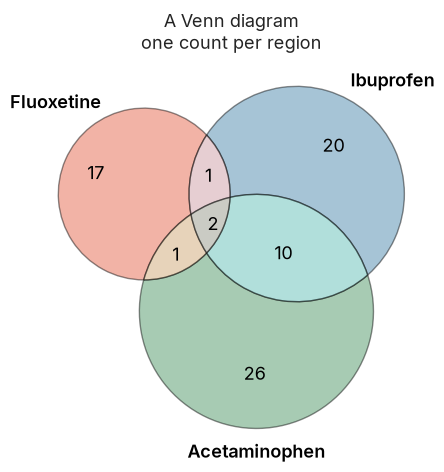

In [1]:
#| code-fold: true
#| fig-cap: "A Venn diagram: one count per region."
import os
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib_venn import venn3
from viset import load

fp = "Font" if os.path.isdir("Font") else "../Font"
for f in font_manager.findSystemFonts(fontpaths=[fp]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"

db = "Drug target sample files/" if os.path.isdir("Drug target sample files") else "../Drug target sample files/"
flu = set(load(db + "1. FLUOXETINE_sample.csv", "Gene names", "Fluoxetine").iloc[:, 0])
ibu = set(load(db + "2. IBUPROFEN_sample.csv", "Gene names", "Ibuprofen").iloc[:, 0])
ace = set(load(db + "3. ACETAMINOPHEN_sample.csv", "Gene names", "Acetaminophen").iloc[:, 0])

fig, ax = plt.subplots(figsize=(6.2, 5.2))
v = venn3([flu, ibu, ace], set_labels=("Fluoxetine", "Ibuprofen", "Acetaminophen"),
          set_colors=("#e4573a", "#3a7ca5", "#3c8c57"), alpha=0.45, ax=ax)
for pid in ("100", "010", "001", "110", "101", "011", "111"):
    p = v.get_patch_by_id(pid)
    if p:
        p.set_edgecolor("black"); p.set_linewidth(1.0)
for t in v.set_labels:
    if t:
        t.set_fontsize(13); t.set_fontweight("semibold")
for t in v.subset_labels:
    if t:
        t.set_fontsize(13)
ax.set_title("A Venn diagram\none count per region", fontsize=13, color="#242424")
plt.show()

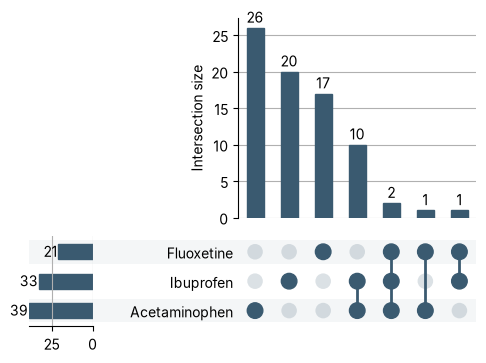

In [2]:
#| code-fold: true
#| fig-cap: "An UpSet plot: bars are intersection sizes; the dot matrix says which sets."
import os
import matplotlib.pyplot as plt
from matplotlib import font_manager
from upsetplot import from_contents, UpSet
from viset import load

fp = "Font" if os.path.isdir("Font") else "../Font"
for f in font_manager.findSystemFonts(fontpaths=[fp]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"

db = "Drug target sample files/" if os.path.isdir("Drug target sample files") else "../Drug target sample files/"
flu = set(load(db + "1. FLUOXETINE_sample.csv", "Gene names", "Fluoxetine").iloc[:, 0])
ibu = set(load(db + "2. IBUPROFEN_sample.csv", "Gene names", "Ibuprofen").iloc[:, 0])
ace = set(load(db + "3. ACETAMINOPHEN_sample.csv", "Gene names", "Acetaminophen").iloc[:, 0])

data = from_contents({"Fluoxetine": flu, "Ibuprofen": ibu, "Acetaminophen": ace})
fig = plt.figure(figsize=(7.4, 4.6))
UpSet(data, sort_by="cardinality", show_counts=True, facecolor="#3a5a70").plot(fig=fig)
plt.show()

Both tell you *how many* genes fall in each region, never *which* ones, and neither shape is drawn to scale. Honest proportions and visible members are exactly what the existing tools struggle with. Here is how close they get.

## Proportional shapes

For a diagram to be honest, each region's **area** should match its **count**. matplotlib's set-diagram tools all draw with **circles**, which can only resize, never reshape, so the areas cannot all fit at once. Take three sets of 82 genes that share 22 in every pair but only **2** in the centre: an honest picture draws that centre as a sliver.

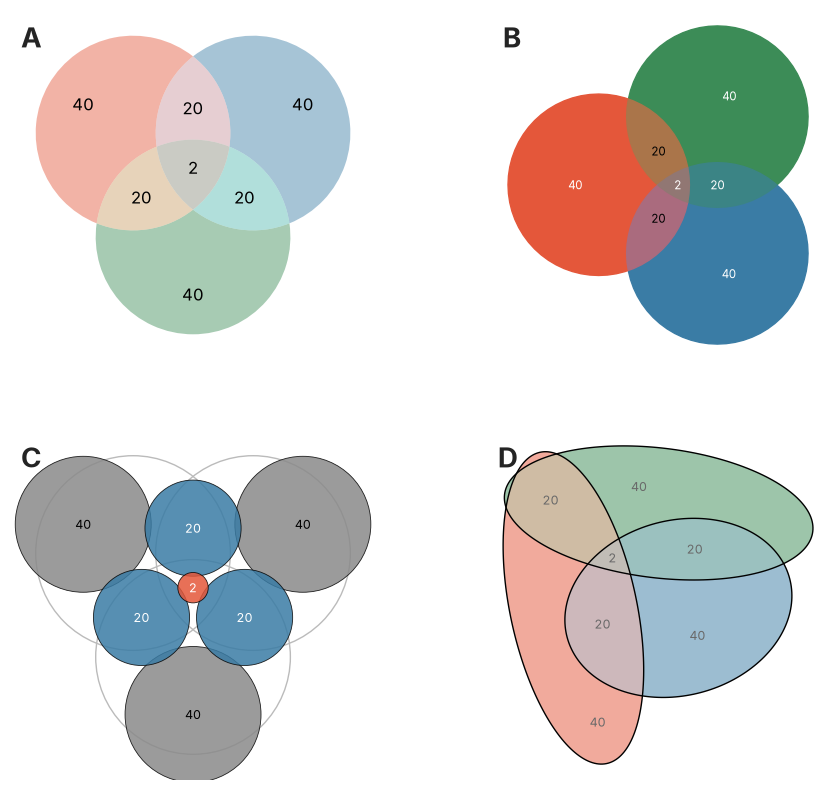

In [3]:
#| code-fold: true
#| fig-cap: "The same three sets (each 82 genes, sharing 22 in every pair and only 2 in the common centre), drawn four ways. (A) A plain Venn from `matplotlib_venn`: the circles are a fixed shape, so the centre is drawn as large as any region despite holding just 2 genes. (B) `matplotlib-set-diagrams` in its Euler mode resizes the circles to the counts, but a circle still cannot shrink the centre to its true size. (C) The true areas, each region a bubble whose area equals its count, so the centre 2 becomes the tiny dot it should be, though the regions no longer join into one diagram. (D) eunoia relaxes the circles into ellipses, which stretch and rotate, recovering a single connected diagram in which every region, the tiny centre included, is area-true."
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib import font_manager
import eunoia
from matplotlib_venn import venn3, venn3_circles
from matplotlib_set_diagrams import EulerDiagram

fp = "Font" if os.path.isdir("Font") else "../Font"
for f in font_manager.findSystemFonts(fontpaths=[fp]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"
RED, BLUE, GREEN, GRY, INK = "#e4573a", "#3a7ca5", "#3c8c57", "#8a8a8a", "#242424"

# venn3 order: A-only, B-only, AB, C-only, AC, BC, ABC ; each set = 82, each pair = 22, centre = 2
d1 = (40, 40, 20, 40, 20, 20, 2)
codes = ["100", "010", "110", "001", "101", "011", "111"]
regmap = {"100": (0,), "010": (1,), "110": (0, 1), "001": (2,), "101": (0, 2), "011": (1, 2), "111": (0, 1, 2)}
counter = [0]
def gene():
    counter[0] += 1
    return "g%05d" % counter[0]
sets = [set(), set(), set()]
for code, cnt in zip(codes, d1):
    members = [gene() for _ in range(cnt)]
    for k in regmap[code]:
        sets[k].update(members)
excl = {"A": 40, "B": 40, "C": 40, "A&B": 20, "A&C": 20, "B&C": 20, "A&B&C": 2}

fig, ax = plt.subplots(2, 2, figsize=(11, 10))
for a in ax.ravel():
    a.set_aspect("equal"); a.axis("off")

# A - matplotlib_venn (circles)
v = venn3(subsets=d1, set_labels=("", "", ""), set_colors=(RED, BLUE, GREEN), alpha=0.45, ax=ax[0, 0])
for t in v.subset_labels:
    if t:
        t.set_fontsize(12)

# B - matplotlib-set-diagrams Euler (circles)
EulerDiagram.from_sets(sets, set_labels=["", "", ""], set_colors=[RED, BLUE, GREEN], ax=ax[0, 1])

# C - true areas as bubbles: circle area = count, so the centre "2" becomes a tiny dot
a = ax[1, 0]
v2 = venn3(subsets=d1, set_labels=("", "", ""), ax=a)
for code in codes:
    p = v2.get_patch_by_id(code)
    if p:
        p.set_visible(False)
rc = venn3_circles(subsets=d1, ax=a, color="#bbbbbb", lw=1.0)[0].radius
for code, cnt in zip(codes, d1):
    lab = v2.get_label_by_id(code)
    pos = lab.get_position()
    lab.set_text("")
    ones = code.count("1")
    a.add_patch(Circle(pos, rc * np.sqrt(cnt / 82.0),
                       facecolor=(RED if ones == 3 else BLUE if ones == 2 else GRY),
                       alpha=0.85, edgecolor="black", lw=0.6, zorder=5))
    a.text(pos[0], pos[1], str(cnt), ha="center", va="center", fontsize=9,
           color="white" if ones >= 2 else "black", zorder=6)
a.relim(); a.autoscale_view(); a.margins(0.15)

# D - eunoia ellipses (reshape) with counts; seed fixed for a clean, symmetric layout
fit = eunoia.euler(excl, input="exclusive", shape="ellipse", seed=0, n_restarts=40)
fit.plot(ax=ax[1, 1], quantities=True, labels=False, colors=[RED, BLUE, GREEN])

for a, letter in zip(ax.ravel(), "ABCD"):
    a.text(0.03, 0.97, letter, transform=a.transAxes, fontsize=20, fontweight="bold", color=INK, va="top", ha="left")
plt.show()

**A** and **B** are the two matplotlib options, both stuck with circles that cannot shrink the centre. **C** draws every region true to size, so the "2" finally becomes a dot, but the regions fall apart into a loose scatter of bubbles rather than one connected diagram. **D** is the fix: [eunoia](https://github.com/jolars/eunoia) (a Python port of R's [eulerr](https://github.com/jolars/eulerr)) relaxes the circles into **ellipses**, which can change shape as well as size, and recovers a single connected diagram where every region, the tiny centre included, is area-true. That ellipse engine is what VISET builds on.

## Showing the members

Proportions aside, the other half of the problem is showing *which* genes, not just how many. One tool already prints them: [`matplotlib-set-diagrams`](https://pypi.org/project/matplotlib-set-diagrams/) fills each region with a **word cloud**. But a word cloud misleads on size: every gene appears once, so there is nothing for size to encode, yet the layout still draws some genes far larger than others (a gene twice as tall as its neighbour simply landed first). You also cannot scan the members as a list, there is no UpSet counterpart, and no hover.

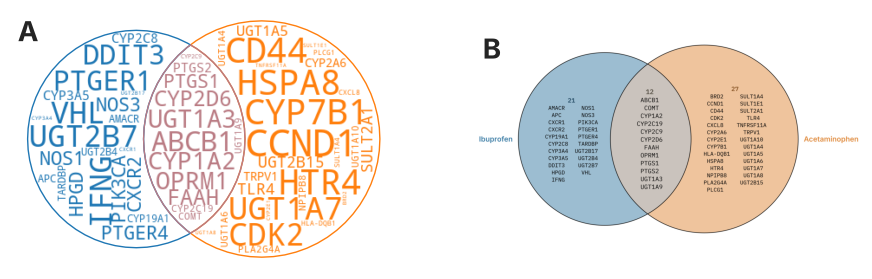

In [4]:
#| code-fold: true
#| fig-cap: "The same two-set overlap, itemized two ways. (A) `matplotlib-set-diagrams` draws a word cloud: the gene sizes vary wildly but carry no meaning, because each gene occurs once and the size only reflects the order the words were packed in. (B) VISET prints every gene at the same size in aligned columns, so the region reads like a list you can check name by name."
import os, tempfile
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib_set_diagrams import EulerDiagram
from IPython.utils.capture import capture_output
from viset import load, eunoia_venn

fp = "Font" if os.path.isdir("Font") else "../Font"
for f in font_manager.findSystemFonts(fontpaths=[fp]):
    font_manager.fontManager.addfont(f)

db = "Drug target sample files/" if os.path.isdir("Drug target sample files") else "../Drug target sample files/"
ibu_df = load(db + "2. IBUPROFEN_sample.csv", "Gene names", "Ibuprofen")
ace_df = load(db + "3. ACETAMINOPHEN_sample.csv", "Gene names", "Acetaminophen")
ibu, ace = set(ibu_df.iloc[:, 0]), set(ace_df.iloc[:, 0])

# VISET renders its own figure, so draw it to an image here (capture_output stops
# that figure from displaying on its own) and place it beside the word cloud below.
viset_png = os.path.join(tempfile.gettempdir(), "viset_side.png")
plt.rcParams["font.family"] = "IBM Plex Mono"
with capture_output():
    eunoia_venn([ibu_df, ace_df], colors=["#3a7ca5", "#e08a3c"], style="round", title="",
                figsize=(10, 8), save_path=viset_png)
plt.close("all")

plt.rcParams["font.family"] = "Inter"
fig, axes = plt.subplots(1, 2, figsize=(11, 4.7))
EulerDiagram.as_wordcloud([ibu, ace], set_labels=["", ""], ax=axes[0],
                          wordcloud_kwargs={"random_state": 0})
axes[1].imshow(plt.imread(viset_png)); axes[1].axis("off")
for a, letter in zip(axes, "AB"):
    a.text(0.02, 0.98, letter, transform=a.transAxes, fontsize=20, fontweight="bold",
           color="#242424", va="top", ha="left")
plt.show()

So each existing tool solves only part of the problem: proportional *or* itemized, never both, never auto-sized to fit, and rarely for UpSet. Closing that gap is what VISET does, on these same gene sets. See the [Introduction](introduction.html).